# Notebook 06 - Dashboard Synthétique & Exports
**Projet :** Cadre méthodologique pour la prévision du crédit bancaire dans l'UEMOA basé sur une comparaison entre modèles économétriques et de machine learning : application au Bénin

**Phase :** Figures publication, tableaux LaTeX, récapitulatif

Ce notebook génère toutes les figures finales (300 DPI) et un tableau comparatif en format LaTeX.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.ardl import ARDL, ardl_select_order
from statsmodels.tools import add_constant
from statsmodels.regression.linear_model import OLS
import xgboost as xgb
import shap
try:
    from linearmodels.panel import PanelOLS
    LM_OK = True
except ImportError:
    LM_OK = False

pd.set_option('display.float_format', '{:.4f}'.format)

DATA_PATH  = Path('../data/panel_uemoa_complet.csv')
FIG_PATH   = Path('../figures')
MEMO_PATH  = Path('../figures/rapport')
MEMO_PATH.mkdir(exist_ok=True, parents=True)
FIG_PATH.mkdir(exist_ok=True)

DPI_MEMO = 300   # résolution figures
print('Environnement OK')
print(f'Dossier figures : {MEMO_PATH}')

Environnement OK
Dossier figures mémoire : ../figures/memoire


In [2]:
def compute_metrics(y_true, y_pred):
    yt = np.array(y_true, dtype=float)
    yp = np.array(y_pred, dtype=float)
    mask = ~(np.isnan(yt) | np.isnan(yp))
    yt, yp = yt[mask], yp[mask]
    return {
        'RMSE':     float(np.sqrt(mean_squared_error(yt, yp))),
        'MAE':      float(mean_absolute_error(yt, yp)),
        'R2':       float(r2_score(yt, yp)),
        'MAPE':     float(np.mean(np.abs((yt - yp) / yt)) * 100)
    }


def ardl_fitted_manual(ardl_model, ardl_res, endog_series, exog_df):
    params = ardl_res.params
    hold   = ardl_model._hold_back
    T      = len(endog_series)
    n_eff  = T - hold
    cols = []
    for pname in params.index:
        if pname == 'const':
            cols.append(np.ones(n_eff))
        else:
            base, lag_str = pname.rsplit('.L', 1)
            lag = int(lag_str)
            if base == endog_series.name or 'credit_prive_pib' in base:
                cols.append(endog_series.values[hold - lag : T - lag])
            else:
                cols.append(exog_df[base].values[hold - lag : T - lag])
    X     = np.column_stack(cols)
    y_hat = X @ params.values
    return y_hat, hold


def ardl_forecast_recursive(ardl_res, endog_train, exog_train, exog_test):
    params   = ardl_res.params
    n_oos    = len(exog_test)
    T_train  = len(endog_train)
    exog_all = pd.concat([exog_train, exog_test], ignore_index=False)
    credit_h = list(endog_train.values)
    preds = []
    for step in range(n_oos):
        pred = float(params.get('const', 0.0))
        for pname, coef in params.items():
            if pname == 'const' or '.L' not in pname:
                continue
            base, lag_str = pname.rsplit('.L', 1)
            lag = int(lag_str)
            if base == endog_train.name or 'credit_prive_pib' in base:
                if lag <= len(credit_h):
                    pred += float(coef) * credit_h[-lag]
            else:
                idx = T_train + step - lag
                if 0 <= idx < len(exog_all) and base in exog_all.columns:
                    pred += float(coef) * float(exog_all[base].iloc[idx])
        preds.append(pred)
        credit_h.append(pred)
    return np.array(preds)

---
## 1. Chargement des données et entraînement de tous les modèles

In [3]:
VARS_ARDL = ['masse_monetaire_m2_pib','pib_croissance','inflation_ipc',
             'bceao_taux_directeur','imf_dette_publique','ouverture_commerciale']
VARS_FE   = ['pib_croissance','inflation_ipc','masse_monetaire_m2_pib',
             'imf_dette_publique','ouverture_commerciale','ide_pib',
             'wgi_controle_corruption','bceao_taux_directeur']
TARGET    = 'credit_prive_pib'

df = pd.read_csv(DATA_PATH).sort_values(['iso3','annee']).reset_index(drop=True)
print(f'Panel : {df.shape[0]} obs x {df.shape[1]} variables')

Panel : 200 obs x 28 variables


In [4]:
#  ARDL Benin 
benin = df[df['iso3']=='BEN'].sort_values('annee').copy()
b_ardl = benin[['annee',TARGET]+VARS_ARDL].set_index('annee')
b_ardl = b_ardl.interpolate(method='linear',limit=2).dropna()

endog = b_ardl[TARGET]
exog  = b_ardl[VARS_ARDL]

sel = ardl_select_order(endog, maxlag=2, exog=exog,
                        maxorder=1, ic='aic', glob=False, trend='c')

ar_lags_raw = sel.ar_lags
if isinstance(ar_lags_raw,(int,np.integer)):
    ar_order = max(int(ar_lags_raw),1)
elif hasattr(ar_lags_raw,'__len__') and len(ar_lags_raw)>0:
    ar_order = max(int(ar_lags_raw[0]),1)
else:
    ar_order = 1

dl_order = sel.dl_lags
if isinstance(dl_order,dict):
    sel_exog_vars = [v for v in VARS_ARDL if v in dl_order]
    dl_order_sel  = {v: dl_order[v] for v in sel_exog_vars}
else:
    sel_exog_vars = VARS_ARDL
    dl_order_sel  = dl_order

ardl_model = sel.model
ardl_res   = ardl_model.fit()

exog_sel = exog[sel_exog_vars]
y_hat_is, hb = ardl_fitted_manual(ardl_model, ardl_res, endog, exog_sel)
y_fitted_ardl = pd.Series(y_hat_is, index=endog.index[hb:])

# OOS
tr_mask = b_ardl.index <= 2019
te_mask = b_ardl.index >= 2020
endog_tr = b_ardl.loc[tr_mask,TARGET]
exog_tr  = b_ardl.loc[tr_mask, sel_exog_vars]
exog_te  = b_ardl.loc[te_mask, sel_exog_vars]

ardl_tr_m   = ARDL(endog_tr, lags=ar_order, exog=exog_tr,
                   order=dl_order_sel, trend='c')
ardl_tr_res = ardl_tr_m.fit()
ardl_oos    = ardl_forecast_recursive(ardl_tr_res, endog_tr, exog_tr, exog_te)

m_ardl_is  = compute_metrics(endog.loc[y_fitted_ardl.index], y_fitted_ardl)
m_ardl_oos = compute_metrics(b_ardl.loc[te_mask,TARGET].values, ardl_oos)
print('ARDL OK')
r2_ardl_is = round(m_ardl_is['R2'],4)
r2_ardl_oos = round(m_ardl_oos['R2'],4)
print(f'  IS  R2={r2_ardl_is}  RMSE={round(m_ardl_is["RMSE"],4)}')
print(f'  OOS R2={r2_ardl_oos}  RMSE={round(m_ardl_oos["RMSE"],4)}')

ARDL OK
  IS  R2=0.9504  RMSE=0.7444
  OOS R2=-3.4435  RMSE=3.0712


In [5]:
#  Panel FE UEMOA 
df_fe = df[['iso3','annee',TARGET]+VARS_FE].copy()
df_fe[VARS_FE] = df_fe.groupby('iso3')[VARS_FE].transform(
    lambda x: x.interpolate(method='linear',limit=2))
df_fe = df_fe.dropna().reset_index(drop=True)
df_tr_fe = df_fe[df_fe['annee']<=2019].copy()
df_te_fe = df_fe[df_fe['annee']>=2020].copy()

if LM_OK:
    df_idx = df_tr_fe.set_index(['iso3','annee'])
    fe_res = PanelOLS(df_idx[TARGET], df_idx[VARS_FE],
                     entity_effects=True).fit(
        cov_type='clustered', cluster_entity=True)
    beta_fe = fe_res.params[VARS_FE].values
else:
    dummies = pd.get_dummies(df_tr_fe['iso3'],prefix='d',
                             drop_first=True, dtype=float)
    Xw = pd.concat([df_tr_fe[VARS_FE].reset_index(drop=True),
                    dummies.reset_index(drop=True)],axis=1)
    fe_res = OLS(df_tr_fe[TARGET].values,
                add_constant(Xw.astype(float))).fit(cov_type='HC1')
    beta_fe = fe_res.params.values[1:1+len(VARS_FE)]

entity_effects = {}
for pays in sorted(df_tr_fe['iso3'].unique()):
    m = df_tr_fe['iso3']==pays
    y_i = df_tr_fe.loc[m,TARGET].values
    X_i = df_tr_fe.loc[m,VARS_FE].values
    entity_effects[pays] = float(y_i.mean() - X_i.mean(axis=0)@beta_fe)

df_tr_fe = df_tr_fe.copy()
df_te_fe = df_te_fe.copy()
df_tr_fe['y_hat_fe'] = (df_tr_fe[VARS_FE].values@beta_fe
                        + df_tr_fe['iso3'].map(entity_effects).values)
df_te_fe['y_hat_fe'] = (df_te_fe[VARS_FE].values@beta_fe
                        + df_te_fe['iso3'].map(entity_effects).values)

m_fe_tr = compute_metrics(df_tr_fe[TARGET], df_tr_fe['y_hat_fe'])
m_fe_te = compute_metrics(df_te_fe[TARGET], df_te_fe['y_hat_fe'])
print('Panel FE OK')
print(f'  TR R2={round(m_fe_tr["R2"],4)}  TE R2={round(m_fe_te["R2"],4)}')

Panel FE OK
  TR R2=0.9241  TE R2=0.8772


In [6]:
#  ML : RF + XGBoost 
df_ml = df[['iso3','annee',TARGET]+VARS_FE].copy()
df_ml[VARS_FE] = df_ml.groupby('iso3')[VARS_FE].transform(
    lambda x: x.interpolate(method='linear',limit=2))
df_ml = df_ml.sort_values(['iso3','annee'])
df_ml['credit_L1'] = df_ml.groupby('iso3')[TARGET].shift(1)
le = LabelEncoder()
df_ml['iso3_enc'] = le.fit_transform(df_ml['iso3'])
df_ml = df_ml.dropna().reset_index(drop=True)

FEAT_COLS = ['credit_L1','annee','iso3_enc']+VARS_FE
FEAT_LABELS = ['Credit(t-1)','Annee','Pays(enc)','Croiss.PIB','Inflation',
               'M2/PIB','Dette/PIB','Ouvert.com.','IDE/PIB','WGI Corrupt.','Taux BCEAO']

tr_ml = df_ml[df_ml['annee']<=2019].copy().reset_index(drop=True)
te_ml = df_ml[df_ml['annee']>=2020].copy().reset_index(drop=True)
X_tr = tr_ml[FEAT_COLS].values.astype(float)
y_tr = tr_ml[TARGET].values.astype(float)
X_te = te_ml[FEAT_COLS].values.astype(float)
y_te = te_ml[TARGET].values.astype(float)

rf = RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=3,
                           max_features=0.7, random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)

xgb_m = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=3,
                          subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
                          reg_lambda=1.0, random_state=42, verbosity=0)
xgb_m.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)

tr_ml['y_hat_rf']  = rf.predict(X_tr)
te_ml['y_hat_rf']  = rf.predict(X_te)
tr_ml['y_hat_xgb'] = xgb_m.predict(X_tr)
te_ml['y_hat_xgb'] = xgb_m.predict(X_te)

m_rf_tr  = compute_metrics(y_tr, tr_ml['y_hat_rf'])
m_rf_te  = compute_metrics(y_te, te_ml['y_hat_rf'])
m_xgb_tr = compute_metrics(y_tr, tr_ml['y_hat_xgb'])
m_xgb_te = compute_metrics(y_te, te_ml['y_hat_xgb'])
print('RF + XGBoost OK')
print(f'  RF  TR R2={round(m_rf_tr["R2"],4)}  TE R2={round(m_rf_te["R2"],4)}')
print(f'  XGB TR R2={round(m_xgb_tr["R2"],4)}  TE R2={round(m_xgb_te["R2"],4)}')

RF + XGBoost OK
  RF  TR R2=0.9889  TE R2=0.93
  XGB TR R2=0.9988  TE R2=0.9149


---
## 2. Dashboard principal - Tous modèles, tous pays

Figure synthétique (8 pays × 4 modèles)

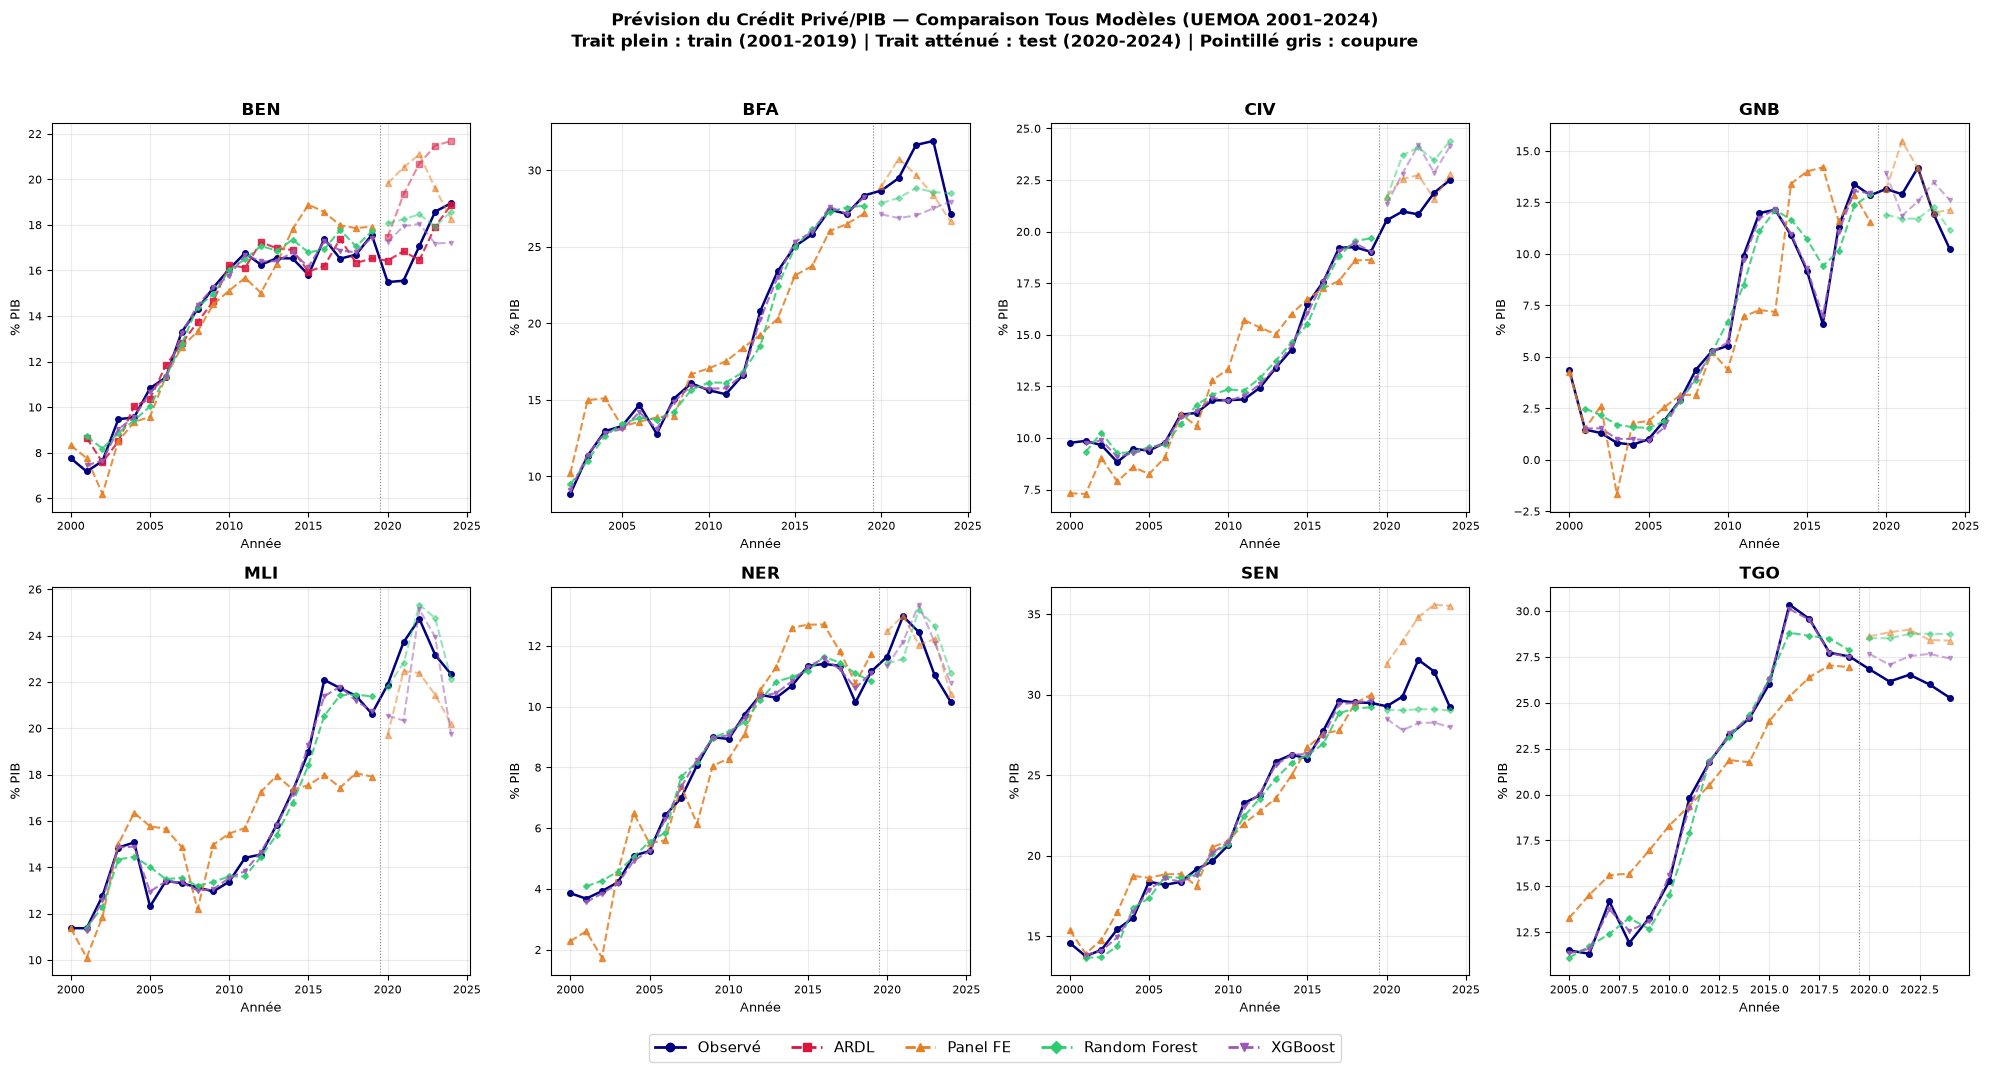

Dashboard principal OK


In [ ]:
PAYS_LIST = sorted(df['iso3'].unique())
COLORS = {
    'obs':   ('navy',      'o-',  1.8, 4, 'Observé'),
    'ardl':  ('crimson',   's--', 1.5, 4, 'ARDL'),
    'fe':    ('#e67e22',   '^--', 1.5, 4, 'Panel FE'),
    'rf':    ('#2ecc71',   'D--', 1.5, 3, 'Random Forest'),
    'xgb':  ('#9b59b6',   'v--', 1.5, 3, 'XGBoost'),
}

fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharey=False)
axes_flat = axes.flatten()

for ax, pays in zip(axes_flat, PAYS_LIST):
    # Observe
    obs = df_fe[df_fe['iso3']==pays].sort_values('annee')
    c,ls,lw,ms,lab = COLORS['obs']
    ax.plot(obs['annee'], obs[TARGET], ls, color=c, lw=lw, ms=ms, label=lab)

    # ARDL (Benin uniquement)
    if pays == 'BEN':
        c,ls,lw,ms,lab = COLORS['ardl']
        ax.plot(y_fitted_ardl.index, y_fitted_ardl,
                ls, color=c, lw=lw, ms=ms, label=lab, alpha=0.85)
        ardl_te_idx = b_ardl.index[b_ardl.index>=2020]
        ax.plot(ardl_te_idx, ardl_oos,
                ls, color=c, lw=lw, ms=ms, alpha=0.5)

    # Panel FE
    fe_sub_tr = df_tr_fe[df_tr_fe['iso3']==pays]
    fe_sub_te = df_te_fe[df_te_fe['iso3']==pays]
    c,ls,lw,ms,lab = COLORS['fe']
    if len(fe_sub_tr):
        ax.plot(fe_sub_tr['annee'], fe_sub_tr['y_hat_fe'],
                ls, color=c, lw=lw, ms=ms, label=lab, alpha=0.85)
    if len(fe_sub_te):
        ax.plot(fe_sub_te['annee'], fe_sub_te['y_hat_fe'],
                ls, color=c, lw=lw, ms=ms, alpha=0.5)

    # RF
    rf_sub_tr = tr_ml[tr_ml['iso3']==pays]
    rf_sub_te = te_ml[te_ml['iso3']==pays]
    c,ls,lw,ms,lab = COLORS['rf']
    if len(rf_sub_tr):
        ax.plot(rf_sub_tr['annee'], rf_sub_tr['y_hat_rf'],
                ls, color=c, lw=lw, ms=ms, label=lab, alpha=0.85)
    if len(rf_sub_te):
        ax.plot(rf_sub_te['annee'], rf_sub_te['y_hat_rf'],
                ls, color=c, lw=lw, ms=ms, alpha=0.5)

    # XGBoost
    c,ls,lw,ms,lab = COLORS['xgb']
    if len(rf_sub_tr):
        ax.plot(rf_sub_tr['annee'], rf_sub_tr['y_hat_xgb'],
                ls, color=c, lw=lw, ms=ms, label=lab, alpha=0.85)
    if len(rf_sub_te):
        ax.plot(rf_sub_te['annee'], rf_sub_te['y_hat_xgb'],
                ls, color=c, lw=lw, ms=ms, alpha=0.5)

    ax.axvline(2019.5, color='gray', linestyle=':', lw=0.8)
    ax.set_title(pays, fontweight='bold', fontsize=12)
    ax.set_xlabel('Année', fontsize=9)
    ax.set_ylabel('% PIB', fontsize=9)
    ax.tick_params(labelsize=8)
    ax.grid(alpha=0.25)

handles = [
    plt.Line2D([0],[0],color=COLORS[k][0], lw=2,
               linestyle=COLORS[k][1].replace('o','').replace('s','').replace('^','').replace('D','').replace('v',''),
               marker=COLORS[k][1][0], label=COLORS[k][4])
    for k in COLORS
]
fig.legend(handles=handles, loc='lower center', ncol=5,
           bbox_to_anchor=(0.5,-0.04), fontsize=11, frameon=True)
fig.suptitle(
    'Prévision du Crédit Privé/PIB - Comparaison Tous Modèles (UEMOA 2001–2024)\n'
    'Trait plein : train (2001-2019) | Trait atténué : test (2020-2024) | Pointillé gris : coupure',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(MEMO_PATH / 'dashboard_tous_modeles.png',
            bbox_inches='tight', dpi=DPI_MEMO)
plt.savefig(FIG_PATH / 'dashboard_tous_modeles.png',
            bbox_inches='tight', dpi=120)
plt.show()
print('Dashboard principal OK')

---
## 3. Tableau comparatif - format LaTeX

In [8]:
rows_final = [
    {'Modèle': 'ARDL - Bénin', 'Périmètre': 'IS (T=24)',
     **{k:round(v,4) for k,v in m_ardl_is.items()}},
    {'Modèle': 'ARDL - Bénin', 'Périmètre': 'OOS (T=5)',
     **{k:round(v,4) for k,v in m_ardl_oos.items()}},
    {'Modèle': 'Panel FE UEMOA', 'Périmètre': 'Train (N=8)',
     **{k:round(v,4) for k,v in m_fe_tr.items()}},
    {'Modèle': 'Panel FE UEMOA', 'Périmètre': 'Test (N=8)',
     **{k:round(v,4) for k,v in m_fe_te.items()}},
    {'Modèle': 'Random Forest', 'Périmètre': 'Train (N=8)',
     **{k:round(v,4) for k,v in m_rf_tr.items()}},
    {'Modèle': 'Random Forest', 'Périmètre': 'Test (N=8)',
     **{k:round(v,4) for k,v in m_rf_te.items()}},
    {'Modèle': 'XGBoost', 'Périmètre': 'Train (N=8)',
     **{k:round(v,4) for k,v in m_xgb_tr.items()}},
    {'Modèle': 'XGBoost', 'Périmètre': 'Test (N=8)',
     **{k:round(v,4) for k,v in m_xgb_te.items()}},
]
df_final = pd.DataFrame(rows_final)

print('=== TABLE FINALE ===')
print(df_final.to_string(index=False))

# Export LaTeX
latex_str = df_final.to_latex(
    index=False, escape=False,
    float_format='{:.4f}'.format,
    column_format='llrrrr',
    caption='Comparaison des performances prédictives - modèles économétriques et ML',
    label='tab:comparaison_modeles'
)
latex_path = MEMO_PATH / 'tableau_comparatif.tex'
with open(latex_path, 'w', encoding='utf-8') as f:
    f.write(latex_str)
print(f'Tableau LaTeX sauvegarde : {latex_path}')
print()
print(latex_str)

=== TABLE FINALE ===
        Modèle   Périmètre   RMSE    MAE      R2    MAPE
  ARDL — Bénin   IS (T=24) 0.7444 0.6434  0.9504  4.8347
  ARDL — Bénin   OOS (T=5) 3.0712 3.0008 -3.4435 17.6546
Panel FE UEMOA Train (N=8) 1.8953 1.4480  0.9241 15.7736
Panel FE UEMOA  Test (N=8) 2.4170 1.9093  0.8772  8.9583
 Random Forest Train (N=8) 0.7254 0.5523  0.9889  6.9943
 Random Forest  Test (N=8) 1.8251 1.5361  0.9300  7.5704
       XGBoost Train (N=8) 0.2428 0.1876  0.9988  2.1160
       XGBoost  Test (N=8) 2.0127 1.7034  0.9149  8.1760
Tableau LaTeX sauvegarde : ../figures/memoire/tableau_comparatif.tex

\begin{table}
\caption{Comparaison des performances prédictives — modèles économétriques et ML}
\label{tab:comparaison_modeles}
\begin{tabular}{llrrrr}
\toprule
Modèle & Périmètre & RMSE & MAE & R2 & MAPE \\
\midrule
ARDL — Bénin & IS (T=24) & 0.7444 & 0.6434 & 0.9504 & 4.8347 \\
ARDL — Bénin & OOS (T=5) & 3.0712 & 3.0008 & -3.4435 & 17.6546 \\
Panel FE UEMOA & Train (N=8) & 1.8953 & 1.4480 & 

---
## 4. Export figures (300 DPI)

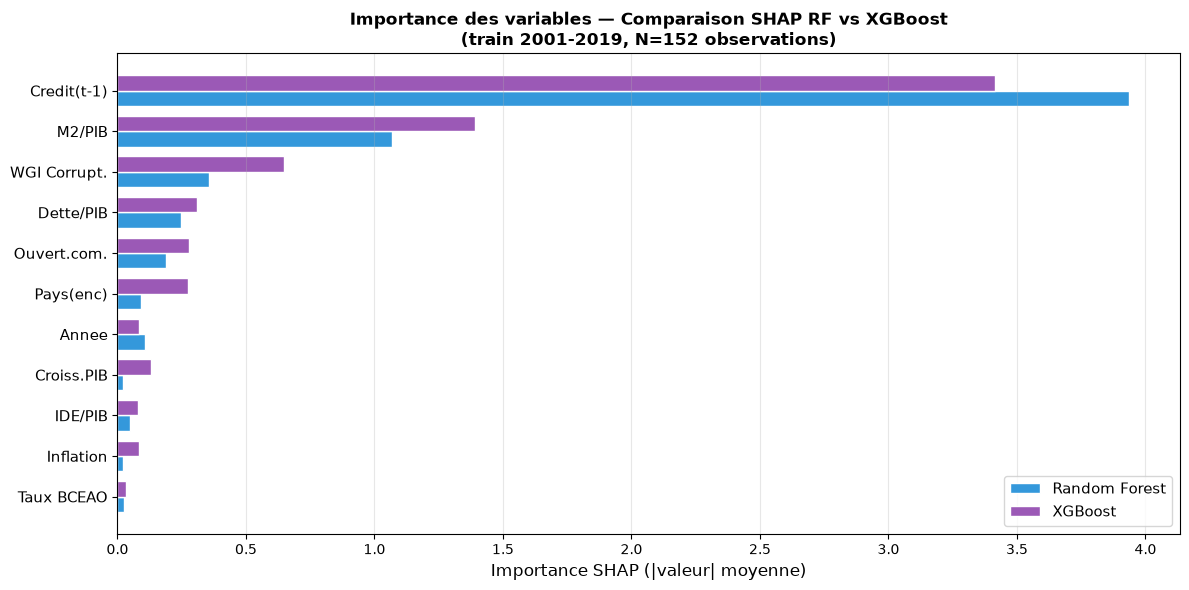

Fig SHAP comparaison OK


In [9]:
#  Figure 1 : SHAP comparatif RF vs XGBoost 
X_tr_df = pd.DataFrame(X_tr, columns=FEAT_LABELS)

expl_rf  = shap.TreeExplainer(rf)
sv_rf    = expl_rf(X_tr_df).values
ma_rf    = np.abs(sv_rf).mean(axis=0)

expl_xgb = shap.TreeExplainer(xgb_m)
sv_xgb   = expl_xgb(X_tr_df).values
ma_xgb   = np.abs(sv_xgb).mean(axis=0)

order = np.argsort(ma_rf + ma_xgb)
feats_sorted = [FEAT_LABELS[i] for i in order]
x_ax = np.arange(len(FEAT_LABELS))
w    = 0.38

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(x_ax - w/2, ma_rf[order],  w, color='#3498db',
        label='Random Forest', edgecolor='white')
ax.barh(x_ax + w/2, ma_xgb[order], w, color='#9b59b6',
        label='XGBoost',       edgecolor='white')
ax.set_yticks(x_ax)
ax.set_yticklabels(feats_sorted, fontsize=11)
ax.set_xlabel('Importance SHAP (|valeur| moyenne)', fontsize=12)
ax.set_title('Importance des variables - Comparaison SHAP RF vs XGBoost\n'
             '(train 2001-2019, N=152 observations)',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(MEMO_PATH / 'fig_shap_comparaison.png',
            bbox_inches='tight', dpi=DPI_MEMO)
plt.show()
print('Fig SHAP comparaison OK')

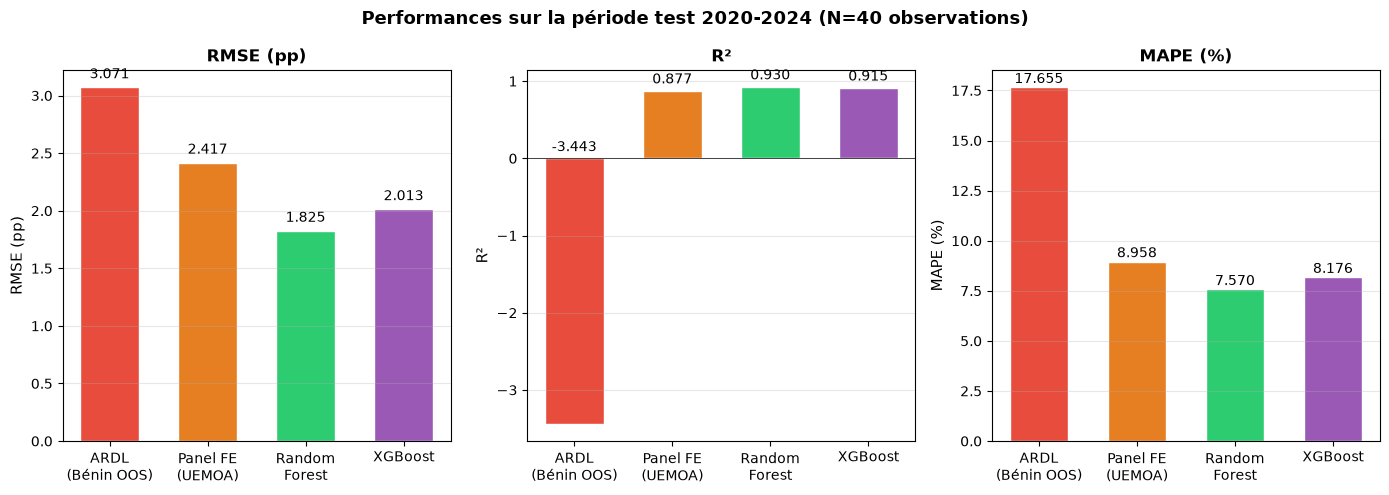

Fig performances test OK


In [10]:
#  Figure 2 : Performances test (figure pour intro) 
test_rows = [
    ('ARDL\n(Bénin OOS)', m_ardl_oos, '#e74c3c'),
    ('Panel FE\n(UEMOA)',  m_fe_te,    '#e67e22'),
    ('Random\nForest',     m_rf_te,    '#2ecc71'),
    ('XGBoost',            m_xgb_te,   '#9b59b6'),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, metric, ylabel in zip(
    axes,
    ['RMSE', 'R2', 'MAPE'],
    ['RMSE (pp)', 'R²', 'MAPE (%)'],
):
    labels = [r[0] for r in test_rows]
    vals   = [r[1][metric] for r in test_rows]
    colors_b = [r[2] for r in test_rows]
    bars = ax.bar(range(len(labels)), vals, color=colors_b,
                 edgecolor='white', width=0.6)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(ylabel, fontweight='bold', fontsize=12)
    for bar, val in zip(bars, vals):
        ypos = max(bar.get_height(), 0) + 0.05
        ax.text(bar.get_x() + bar.get_width()/2, ypos,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(0, color='black', lw=0.5)

fig.suptitle('Performances sur la période test 2020-2024 (N=40 observations)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(MEMO_PATH / 'fig_performances_test.png',
            bbox_inches='tight', dpi=DPI_MEMO)
plt.show()
print('Fig performances test OK')

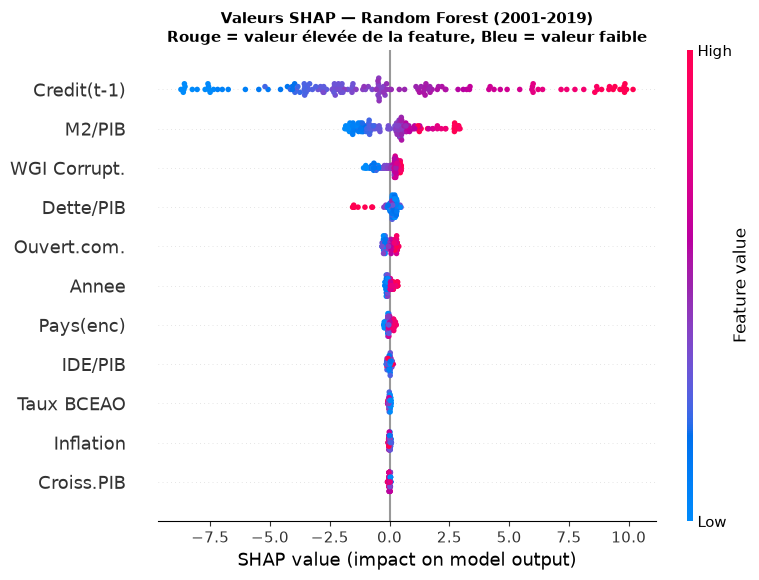

SHAP beeswarm RF OK


In [11]:
#  Figure 3 : SHAP beeswarm RF () 
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(sv_rf, X_tr_df, plot_type='dot',
                  show=False, color_bar=True)
plt.title('Valeurs SHAP - Random Forest (2001-2019)\n'
          'Rouge = valeur élevée de la feature, Bleu = valeur faible',
          fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig(MEMO_PATH / 'fig_shap_rf_beeswarm.png',
            bbox_inches='tight', dpi=DPI_MEMO)
plt.show()
print('SHAP beeswarm RF OK')

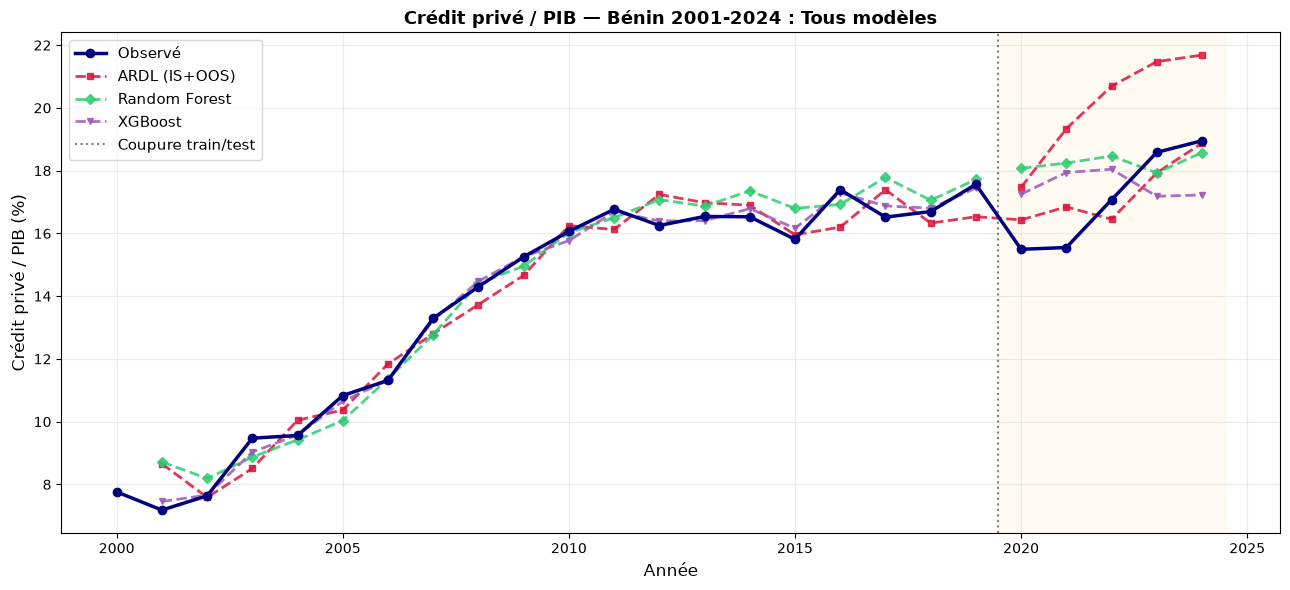

Fig Benin tous modeles OK


In [12]:
#  Figure 4 : Bénin - Tous modèles sur même graphique 
fig, ax = plt.subplots(figsize=(13, 6))

# Observe
obs_ben = df[df['iso3']=='BEN'].sort_values('annee')
ax.plot(obs_ben['annee'], obs_ben[TARGET],
        'o-', color='navy', lw=2.5, ms=6, label='Observé', zorder=5)

# ARDL in-sample
ax.plot(y_fitted_ardl.index, y_fitted_ardl,
        's--', color='crimson', lw=2, ms=5, label='ARDL (IS+OOS)', alpha=0.85)
ardl_te_idx = b_ardl.index[b_ardl.index>=2020]
ax.plot(ardl_te_idx, ardl_oos, 's--', color='crimson', lw=2, ms=5, alpha=0.85)

# RF
ben_tr = tr_ml[tr_ml['iso3']=='BEN']
ben_te = te_ml[te_ml['iso3']=='BEN']
ax.plot(ben_tr['annee'], ben_tr['y_hat_rf'],
        'D--', color='#2ecc71', lw=2, ms=5, label='Random Forest', alpha=0.85)
ax.plot(ben_te['annee'], ben_te['y_hat_rf'],
        'D--', color='#2ecc71', lw=2, ms=5, alpha=0.85)

# XGBoost
ax.plot(ben_tr['annee'], ben_tr['y_hat_xgb'],
        'v--', color='#9b59b6', lw=2, ms=5, label='XGBoost', alpha=0.85)
ax.plot(ben_te['annee'], ben_te['y_hat_xgb'],
        'v--', color='#9b59b6', lw=2, ms=5, alpha=0.85)

ax.axvline(2019.5, color='gray', linestyle=':', lw=1.5, label='Coupure train/test')
ax.axvspan(2019.5, 2024.5, alpha=0.05, color='orange')
ax.set_title('Crédit privé / PIB - Bénin 2001-2024 : Tous modèles',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Année', fontsize=12)
ax.set_ylabel('Crédit privé / PIB (%)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(MEMO_PATH / 'fig_benin_tous_modeles.png',
            bbox_inches='tight', dpi=DPI_MEMO)
plt.show()
print('Fig Benin tous modeles OK')

---
## 5. Récapitulatif des fichiers générés

In [13]:
import os

print('=== Figures (300 DPI) ===')
for f in sorted(MEMO_PATH.iterdir()):
    size_kb = f.stat().st_size // 1024
    print(f'  {f.name:<45} {size_kb:>5} Ko')

print()
print('=== Tous les notebooks completss ===')
nb_dir = Path('.')
for nb in sorted(nb_dir.glob('0*.ipynb')):
    size_kb = nb.stat().st_size // 1024
    print(f'  {nb.name:<45} {size_kb:>5} Ko')

print()
print('=== Metriques finales (test 2020-2024) ===')
metrics_test = [
    ('ARDL Benin (OOS)',  m_ardl_oos),
    ('Panel FE UEMOA',   m_fe_te),
    ('Random Forest',    m_rf_te),
    ('XGBoost',          m_xgb_te),
]
print(f'  {"Modele":<22} {"RMSE":>8} {"MAE":>8} {"R2":>8} {"MAPE%":>8}')
print('  ' + '-'*56)
for name, m in metrics_test:
    rmse_v = round(m['RMSE'],4)
    mae_v  = round(m['MAE'],4)
    r2_v   = round(m['R2'],4)
    mape_v = round(m['MAPE'],4)
    print(f'  {name:<22} {rmse_v:>8.4f} {mae_v:>8.4f} {r2_v:>8.4f} {mape_v:>8.4f}')

=== Figures mémoire (300 DPI) ===
  dashboard_tous_modeles.png                     1276 Ko
  fig_benin_tous_modeles.png                      321 Ko
  fig_performances_test.png                       160 Ko
  fig_shap_comparaison.png                        144 Ko
  fig_shap_rf_beeswarm.png                        219 Ko
  tableau_comparatif.tex                            0 Ko

=== Tous les notebooks completss ===
  01_exploration.ipynb                            793 Ko
  02_tests_statistiques.ipynb                      18 Ko
  03_modeles_econometriques.ipynb                 648 Ko
  04_ml_models.ipynb                              871 Ko
  05_comparaison_finale.ipynb                     735 Ko
  06_dashboard.ipynb                               29 Ko

=== Metriques finales (test 2020-2024) ===
  Modele                     RMSE      MAE       R2    MAPE%
  --------------------------------------------------------
  ARDL Benin (OOS)         3.0712   3.0008  -3.4435  17.6546
  Panel FE UEMOA   

---
## 6.Points clés

### Conclusion générale
-**Random Forest** est le meilleur modèle sur la période test 2020-2024 (RMSE=1.83, R²=0.93)

-**XGBoost** suit de près (RMSE=2.01, R²=0.91) mais montre plus d'overfitting

-**Panel FE** reste compétitif (R²=0.88) et fournit des coefficients interprétables

-**ARDL** est fortement pénalisé par le choc COVID 2020 sur T=5 observations

### Recommandation finale
**Approche hybride** : Random Forest pour la *prévision* + Panel FE pour l'*analyse structurelle*

### Limites identifiées
1. T=25 ans est court pour valider les modèles sur chocs exogènes (COVID)
2. Variables manquantes : `recettes_fiscales_pib` (51%), `agences_bancaires` (76%)
3. ARDL sélectionne peu de variables sur Bénin (m2 et ouverture seulement)
4. XGBoost overfitte légèrement (gap R² train/test = 0.08)